In [7]:
import yfinance as yf
import numpy as np
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [8]:
end_date = datetime.strptime('2020-01-01', '%Y-%m-%d')
start_date = end_date - timedelta(days=365*5)

In [9]:
tickers = ['GOOGL', 'TSLA', 'AMZN', 'JPM', 'XOM', 'ASML', 'RACE', 'SIE.DE', 'GLD', 'BTC-USD']

returns_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    returns_df[ticker] = data['Close'].pct_change()

returns_df = returns_df.dropna() 
print(returns_df.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2015-11-01  0.034527  0.112743  0.062151  0.045309 -0.013053 -0.000754   
2015-12-01  0.019873  0.042343  0.016682 -0.009748 -0.037111 -0.042601   
2016-01-01 -0.021414 -0.203367 -0.131515 -0.098894 -0.001283  0.034584   
2016-02-01 -0.057963  0.003818 -0.058739 -0.047434  0.029544 -0.008929   
2016-03-01  0.063690  0.197155  0.074423  0.051865  0.052385  0.102944   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2015-11-01 -0.080904  0.072568 -0.067521  0.201024  
2015-12-01  0.035599 -0.084165 -0.004513  0.141116  
2016-01-01 -0.171458 -0.018914  0.054110 -0.143532  
2016-02-01 -0.045009  0.012546  0.109303  0.186920  
2016-03-01  0.097947  0.089983 -0.008429 -0.047905  


In [10]:
data_rf = yf.download('^TYX', start=start_date, end=end_date, interval='1mo')
rf_annual_pct = data_rf["Close"].mean()
rf = float(rf_annual_pct / 100) 
rf = (1 + rf)**(1/12) - 1  
print(rf)

[*********************100%***********************]  1 of 1 completed

0.0022959950457945855



C:\Users\Riccardo\AppData\Local\Temp\ipykernel_15896\3818144123.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rf = float(rf_annual_pct / 100)


In [11]:
spy_data = yf.download('SPY', start=start_date, end=end_date, interval='1mo')
spy_returns = spy_data["Close"].pct_change()
spy_returns = spy_returns.dropna()
spy_returns = spy_returns.loc[returns_df.index]
spy_mean = float(spy_returns.mean())
spy_var = float(spy_returns.var())

print(spy_returns.head())

[*********************100%***********************]  1 of 1 completed

Ticker           SPY
Date                
2015-11-01  0.003655
2015-12-01 -0.023097
2016-01-01 -0.044131
2016-02-01 -0.000826
2016-03-01  0.061790



C:\Users\Riccardo\AppData\Local\Temp\ipykernel_15896\2182183759.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_mean = float(spy_returns.mean())
C:\Users\Riccardo\AppData\Local\Temp\ipykernel_15896\2182183759.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_var = float(spy_returns.var())


In [12]:
excess_returns = returns_df - rf
print(excess_returns.head())

               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2015-11-01  0.032231  0.110448  0.059855  0.043013 -0.015349 -0.003050   
2015-12-01  0.017577  0.040047  0.014386 -0.012044 -0.039407 -0.044897   
2016-01-01 -0.023710 -0.205663 -0.133811 -0.101190 -0.003579  0.032288   
2016-02-01 -0.060259  0.001522 -0.061035 -0.049730  0.027248 -0.011225   
2016-03-01  0.061394  0.194859  0.072127  0.049569  0.050089  0.100648   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2015-11-01 -0.083200  0.070272 -0.069817  0.198728  
2015-12-01  0.033303 -0.086461 -0.006809  0.138820  
2016-01-01 -0.173754 -0.021210  0.051814 -0.145828  
2016-02-01 -0.047305  0.010250  0.107007  0.184624  
2016-03-01  0.095651  0.087687 -0.010725 -0.050201  


In [13]:
p_excess_returns = spy_returns - rf
print(p_excess_returns.head())

Ticker           SPY
Date                
2015-11-01  0.001359
2015-12-01 -0.025393
2016-01-01 -0.046427
2016-02-01 -0.003122
2016-03-01  0.059494


In [14]:
T = 0
for t in p_excess_returns.iloc:
    T += 1
print(T)

50


In [15]:
re_mean = excess_returns.mean()
f_mean = p_excess_returns.mean()
f_var = p_excess_returns.var()

In [16]:
betas = []
alfas = []

for col in excess_returns.columns:
    num = 0
    den = 0
    
    f_t_values = p_excess_returns["SPY"].astype(float)
    re_t_values = excess_returns[col].astype(float)
    
    f_mean = f_t_values.mean()
    re_mean = re_t_values.mean()
    
    for f_t, re_t in zip(f_t_values, re_t_values):
        num += (f_t - f_mean) * (re_t - re_mean)
        den += (f_t - f_mean) ** 2
    
    beta = num / den
    betas.append(beta)

    alfa = re_t - beta * f_mean
    alfas.append(alfa)

In [17]:
def get_stock_name(ticker_symbol: str):
    ticker = yf.Ticker(ticker_symbol)
    info = ticker.info
    return info.get("longName", "Nome non disponibile")

portfolio = []

for ticker in tickers:
    stock = get_stock_name(ticker)
    portfolio.append(stock)

print(portfolio)

['Alphabet Inc.', 'Tesla, Inc.', 'Amazon.com, Inc.', 'JPMorgan Chase & Co.', 'Exxon Mobil Corporation', 'ASML Holding N.V.', 'Ferrari N.V.', 'Siemens Aktiengesellschaft', 'SPDR Gold Shares', 'Bitcoin USD']


In [18]:
OLS_matrix = pd.DataFrame({
    'Titolo': portfolio,
    'Alpha': alfas,
    'Beta': betas
}, index=excess_returns.columns)
OLS_matrix.index.name = 'Ticker'

print(OLS_matrix)

                             Titolo     Alpha      Beta
Ticker                                                 
GOOGL                 Alphabet Inc.  0.016014  1.014974
TSLA                    Tesla, Inc.  0.258093  0.870043
AMZN               Amazon.com, Inc.  0.010272  1.570588
JPM            JPMorgan Chase & Co.  0.045338  1.199395
XOM         Exxon Mobil Corporation  0.026113  0.945748
ASML              ASML Holding N.V.  0.084866  1.292042
RACE                   Ferrari N.V. -0.029715  1.297275
SIE.DE   Siemens Aktiengesellschaft -0.014715  0.865219
GLD                SPDR Gold Shares  0.035442 -0.136600
BTC-USD                 Bitcoin USD -0.051979  0.000763


In [19]:
errors_matrix = np.zeros((len(alfas), len(alfas)))  # inizializza matrice NxN

for re, f_t in zip(excess_returns.values, p_excess_returns["SPY"].values):
    eps_t = re - np.array(alfas) - np.array(betas) * f_t
    
    errors_matrix += np.outer(eps_t, eps_t)

errors_matrix = errors_matrix / T

errors_matrix_df = pd.DataFrame(errors_matrix, index=tickers, columns=tickers)

print(errors_matrix_df) 

            GOOGL      TSLA      AMZN       JPM       XOM      ASML      RACE  \
GOOGL    0.001857  0.003769  0.000581  0.000120 -0.000092  0.001645 -0.000486   
TSLA     0.003769  0.075340  0.000161  0.009503  0.008429  0.018081 -0.011087   
AMZN     0.000581  0.000161  0.003050 -0.000415 -0.000374 -0.000010  0.001189   
JPM      0.000120  0.009503 -0.000415  0.003296  0.001217  0.002528 -0.002450   
XOM     -0.000092  0.008429 -0.000374  0.001217  0.003016  0.002515 -0.001963   
ASML     0.001645  0.018081 -0.000010  0.002528  0.002515  0.007444 -0.002531   
RACE    -0.000486 -0.011087  0.001189 -0.002450 -0.001963 -0.002531  0.007106   
SIE.DE   0.000139 -0.003427 -0.000481  0.000004 -0.000095 -0.000473  0.000064   
GLD      0.000103  0.008023 -0.000083  0.000355  0.001032  0.002517 -0.000982   
BTC-USD -0.002730 -0.036035  0.000502 -0.005246 -0.006385 -0.012706  0.008410   

           SIE.DE       GLD   BTC-USD  
GOOGL    0.000139  0.000103 -0.002730  
TSLA    -0.003427  0.008023 

In [27]:
mean_matrix = np.zeros(len(alfas))

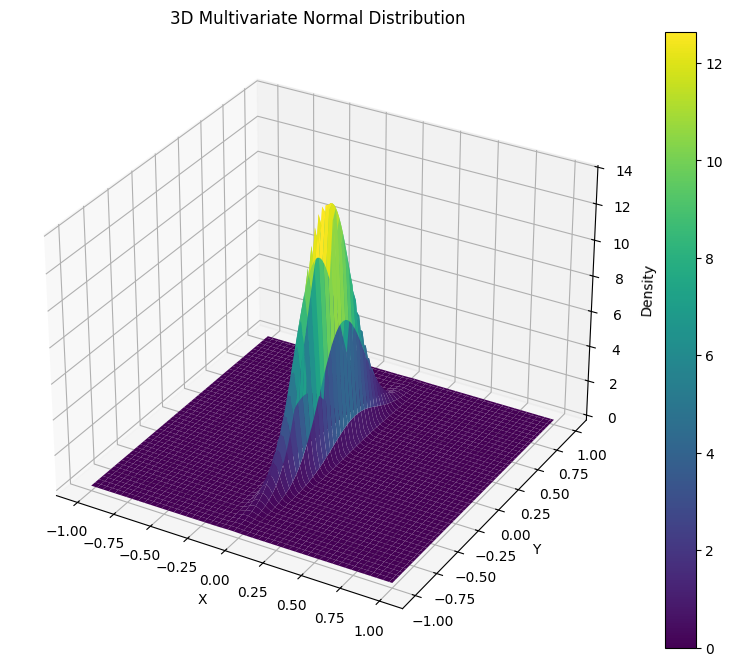

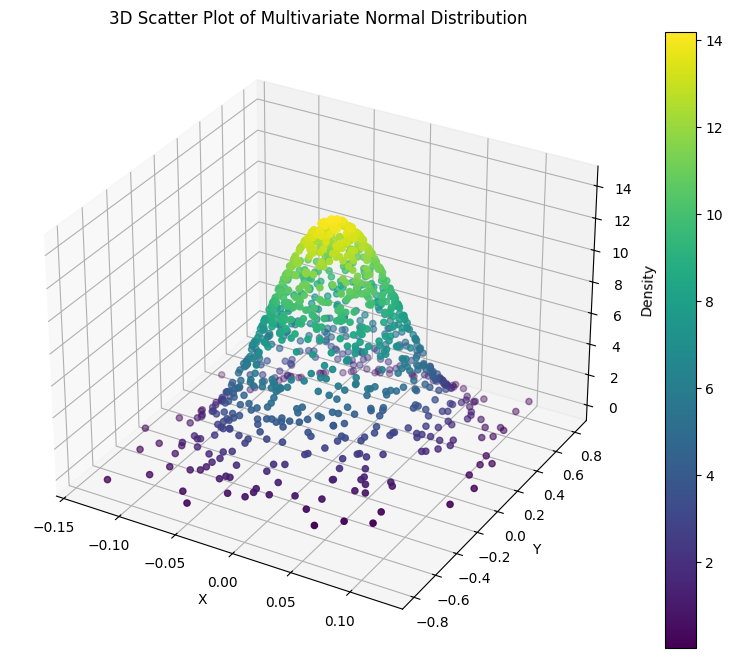

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

# Assumendo che tu voglia visualizzare la distribuzione per due variabili
# Crea una griglia di punti
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

# Prepara i punti per la valutazione della PDF
pos = np.dstack((X, Y))

# Seleziona solo le prime due variabili per la visualizzazione
mean = mean_matrix[:2]  # prendi solo le prime due componenti
cov = errors_matrix[:2, :2]  # prendi solo il blocco 2x2 superiore sinistro

# Crea la distribuzione normale multivariata
rv = multivariate_normal(mean, cov)

# Calcola la PDF
Z = rv.pdf(pos)

# Crea il plot 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot della superficie
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

# Aggiungi una barra dei colori
fig.colorbar(surf)

# Etichette degli assi
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Density')

plt.title('3D Multivariate Normal Distribution')
plt.show()

# Alternativa: scatter plot 3D con un campione dalla distribuzione
# Genera un campione dalla distribuzione
sample = np.random.multivariate_normal(mean, cov, 1000)

# Nuovo plot per lo scatter 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(sample[:, 0], sample[:, 1], rv.pdf(sample), c=rv.pdf(sample), cmap='viridis')

# Aggiungi una barra dei colori
fig.colorbar(scatter)

# Etichette degli assi
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Density')

plt.title('3D Scatter Plot of Multivariate Normal Distribution')
plt.show()